In [54]:
import pandas as pd
import numpy as np

In [55]:
df=pd.read_csv(r"C:\Users\Daniel\Downloads\Python pract\Linear Regression\USA_Housing.csv")
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [56]:
df.shape

(5000, 7)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [58]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [59]:
print(df.describe().applymap(lambda x:f"{x:,.2f}")
 #df.describe().applymap(lambda x: f"{x:,.2f}")

SyntaxError: incomplete input (3524290450.py, line 2)

In [60]:
df.describe().map(lambda x: f"{x:,.2f}")


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,"5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00"
mean,"68,583.11",5.98,6.99,3.98,"36,163.52","1,232,072.65"
std,"10,657.99",0.99,1.01,1.23,"9,925.65","353,117.63"
min,"17,796.63",2.64,3.24,2.00,172.61,"15,938.66"
25%,"61,480.56",5.32,6.30,3.14,"29,403.93","997,577.14"
50%,"68,804.29",5.97,7.00,4.05,"36,199.41","1,232,669.38"
75%,"75,783.34",6.65,7.67,4.49,"42,861.29","1,471,210.20"
max,"107,701.75",9.52,10.76,6.50,"69,621.71","2,469,065.59"


In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols=df.select_dtypes(include=['number']).columns
numeric_cols

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price'],
      dtype='object')

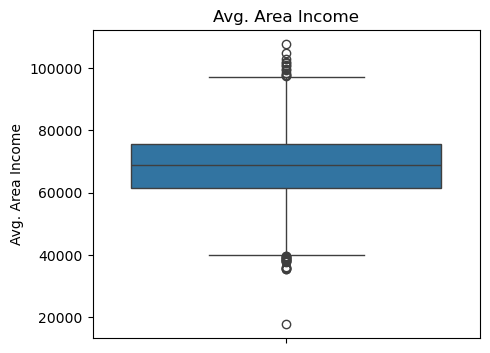

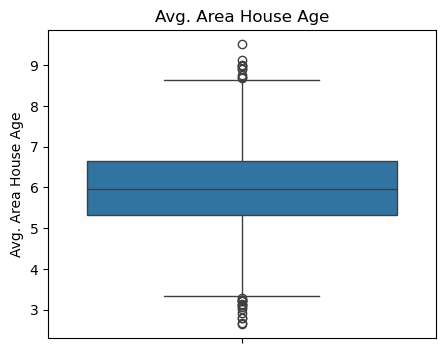

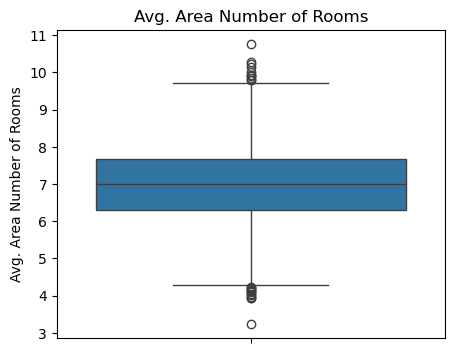

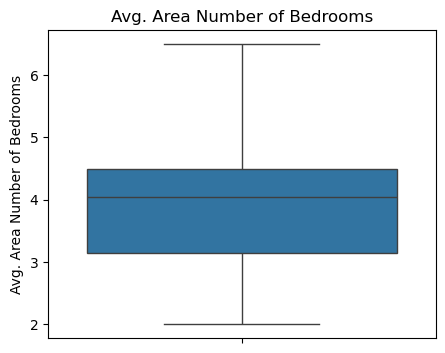

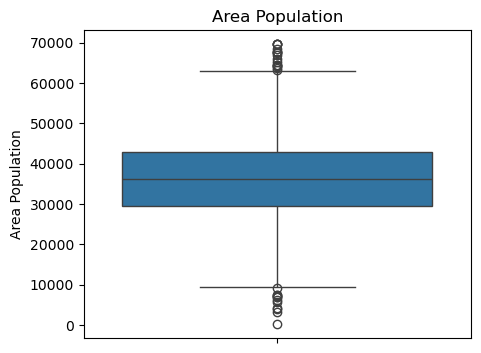

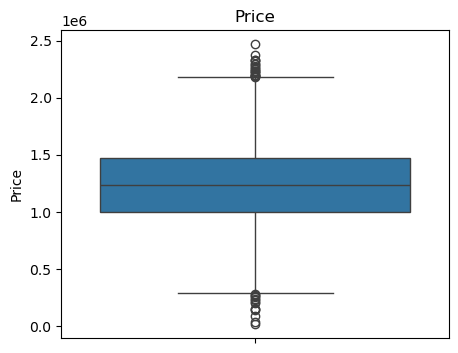

In [62]:
for col in numeric_cols:
    plt.figure(figsize=(5, 4))
    sns.boxplot(y=col,data=df)
    plt.title(f'{col}')
    plt.show()

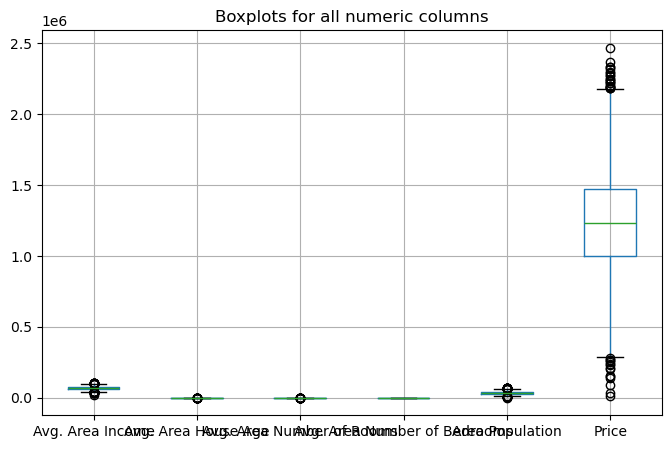

In [63]:
plt.figure(figsize=(8, 5))
df[numeric_cols].boxplot()
plt.title("Boxplots for all numeric columns")
plt.show()


In [64]:
#inter quartile range IQR
q1=df[numeric_cols].quantile(0.25)
q3=df[numeric_cols].quantile(0.75)
IQR=q3-q1
pos_out=q3+1.5*IQR
neg_out=q1-1.5*IQR

In [65]:
print(q1)
print(q3)
print(pos_out)
print(neg_out)

Avg. Area Income                 61480.562388
Avg. Area House Age                  5.322283
Avg. Area Number of Rooms            6.299250
Avg. Area Number of Bedrooms         3.140000
Area Population                  29403.928702
Price                           997577.135049
Name: 0.25, dtype: float64
Avg. Area Income                7.578334e+04
Avg. Area House Age             6.650808e+00
Avg. Area Number of Rooms       7.665871e+00
Avg. Area Number of Bedrooms    4.490000e+00
Area Population                 4.286129e+04
Price                           1.471210e+06
Name: 0.75, dtype: float64
Avg. Area Income                9.723750e+04
Avg. Area House Age             8.643597e+00
Avg. Area Number of Rooms       9.715803e+00
Avg. Area Number of Bedrooms    6.515000e+00
Area Population                 6.304733e+04
Price                           2.181660e+06
dtype: float64
Avg. Area Income                 40026.397972
Avg. Area House Age                  3.329495
Avg. Area Number of Roo

In [66]:
#remove outlier
df=df[~((df[numeric_cols]<(q1-1.5*IQR)) |(df[numeric_cols]>(q3+1.5*IQR))).any(axis=1)]

In [67]:
df.describe

<bound method NDFrame.describe of       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0         79545.458574             5.682861                   7.009188   
1         79248.642455             6.002900                   6.730821   
2         61287.067179             5.865890                   8.512727   
3         63345.240046             7.188236                   5.586729   
4         59982.197226             5.040555                   7.839388   
...                ...                  ...                        ...   
4995      60567.944140             7.830362                   6.137356   
4996      78491.275435             6.999135                   6.576763   
4997      63390.686886             7.250591                   4.805081   
4998      68001.331235             5.534388                   7.130144   
4999      65510.581804             5.992305                   6.792336   

      Avg. Area Number of Bedrooms  Area Population         Price  \
0       

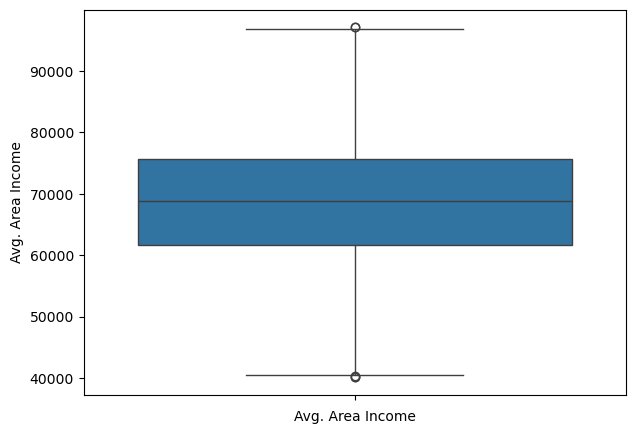

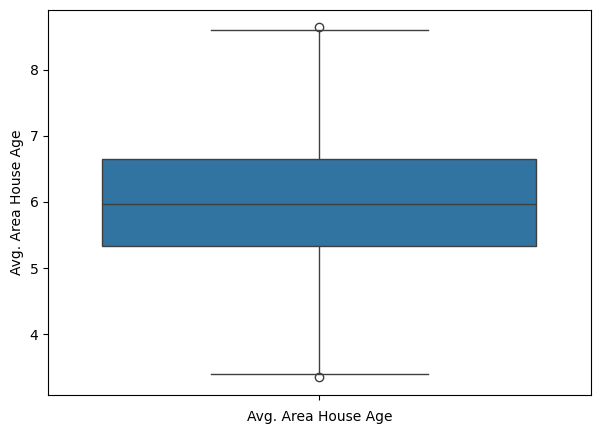

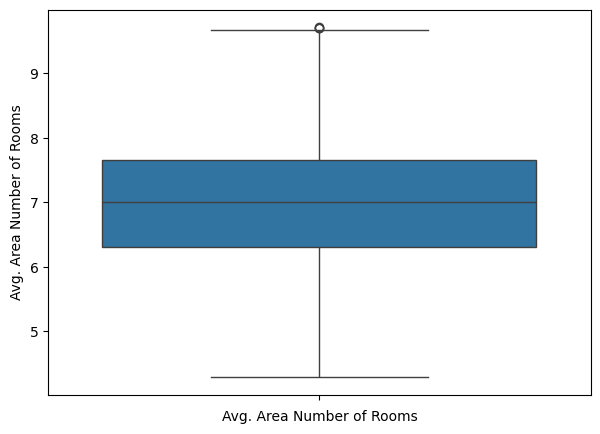

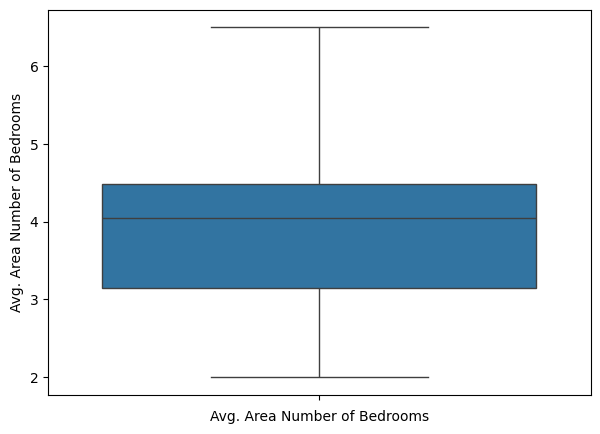

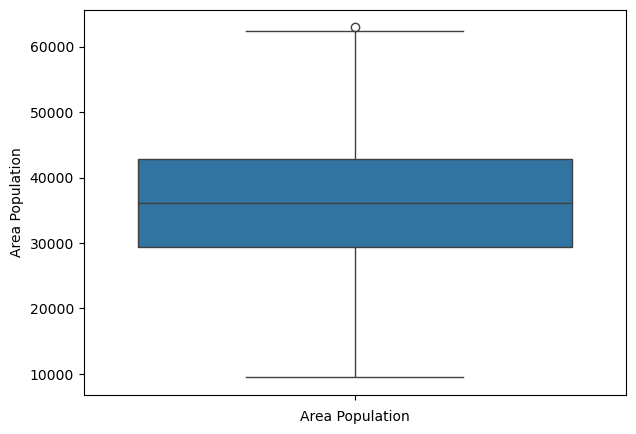

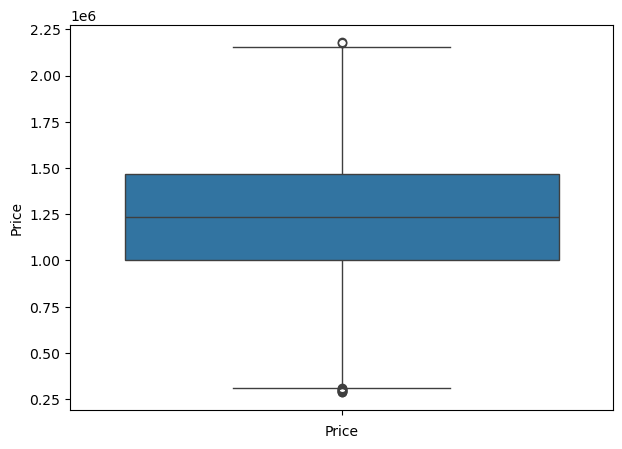

In [68]:
for col in numeric_cols:
    plt.figure(figsize=(7,5))
    sns.boxplot(y=col,data=df)
    plt.xlabel(col)
    plt.show()



In [69]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [70]:
df=df.drop('Address',axis=1)
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


In [71]:
df.corr()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
Avg. Area Income,1.000000,-0.021102,-0.021113,0.012875,-0.014097,0.632031
Avg. Area House Age,-0.021102,1.000000,-0.016919,0.001177,-0.024151,0.441675
Avg. Area Number of Rooms,-0.021113,-0.016919,1.000000,0.466596,-0.000244,0.329630
Avg. Area Number of Bedrooms,0.012875,0.001177,0.466596,1.000000,-0.023172,0.168606
Area Population,-0.014097,-0.024151,-0.000244,-0.023172,1.000000,0.406027
Price,0.632031,0.441675,0.329630,0.168606,0.406027,1.000000


<Axes: >

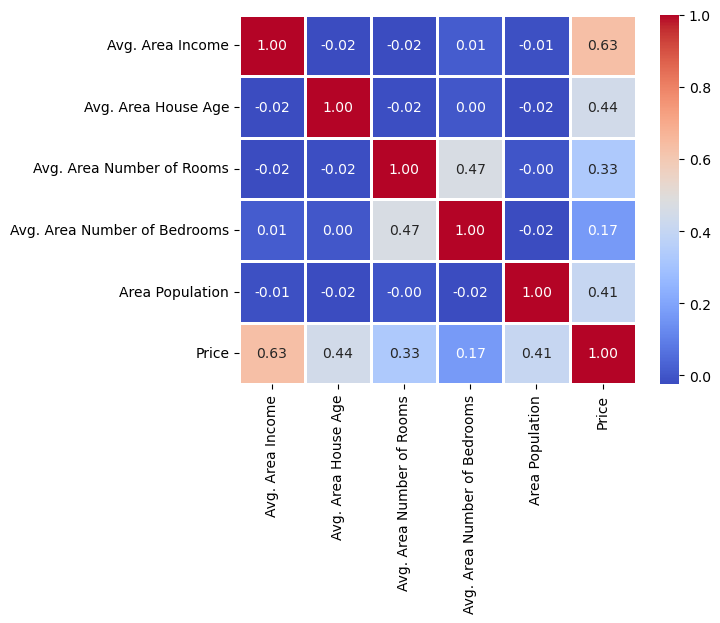

In [72]:
sns.heatmap(df.corr(),cmap='coolwarm',annot=True,fmt='.2f',linewidths=2)

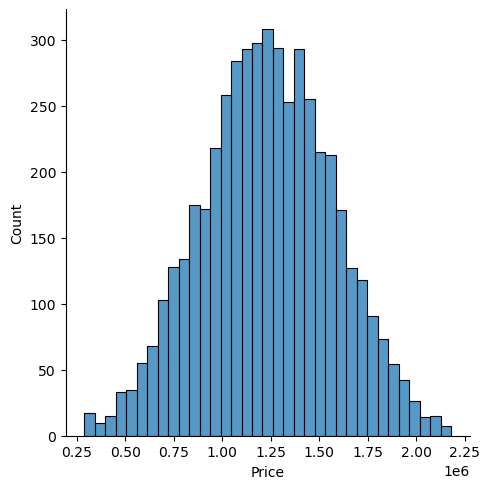

In [73]:
sns.displot(df['Price'])
plt.show()

In [74]:
x=df.drop('Price',axis=1)
y=df['Price']
print(x)
print("printing y"*9)
print(y)

      Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0         79545.458574             5.682861                   7.009188   
1         79248.642455             6.002900                   6.730821   
2         61287.067179             5.865890                   8.512727   
3         63345.240046             7.188236                   5.586729   
4         59982.197226             5.040555                   7.839388   
...                ...                  ...                        ...   
4995      60567.944140             7.830362                   6.137356   
4996      78491.275435             6.999135                   6.576763   
4997      63390.686886             7.250591                   4.805081   
4998      68001.331235             5.534388                   7.130144   
4999      65510.581804             5.992305                   6.792336   

      Avg. Area Number of Bedrooms  Area Population  
0                             4.09     23086.800503  
1  

In [75]:
#column is in category we can apply get dummies our values are all numbers
# df1=pd.getdummies(x,drop_first=True,axis=1)
# df1.head()

In [76]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [77]:
x_val=scaler.fit_transform(x)
x_val

array([[ 1.06071779, -0.30363229,  0.02290907,  0.0859644 , -1.35240284],
       [ 1.03191461,  0.02775903, -0.25978767, -0.72371729,  0.4207993 ],
       [-0.7110857 , -0.11411114,  1.5498338 ,  0.92803335,  0.07927052],
       ...,
       [-0.50694938,  1.31970959, -2.2154799 , -1.50101171, -0.29599705],
       [-0.05953013, -0.45737203,  0.14574608,  1.17903467,  0.67532313],
       [-0.30123371,  0.0167887 , -0.1973158 ,  0.06977076,  1.07753698]])

In [78]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
variable=x_val
vif=pd.DataFrame()
vif['variance_inflation_factor']=[variance_inflation_factor(variable,i) for i in range(variable.shape[1])]

In [79]:
vif['variance_inflation_factor']

0    1.001776
1    1.001451
2    1.280194
3    1.280126
4    1.001448
Name: variance_inflation_factor, dtype: float64

In [80]:
vif['feature']=x.columns

In [81]:
vif

,variance_inflation_factor,feature
0,1.001776,Avg. Area Income
1,1.001451,Avg. Area House Age
2,1.280194,Avg. Area Number of Rooms
3,1.280126,Avg. Area Number of Bedrooms
4,1.001448,Area Population


In [82]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_val,y,test_size=0.3,random_state=70)

In [83]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [84]:
#model should not train with test test
# You are leaking the test set into training.

# The model forgets the first training, because .fit() overwrites everything.

# Now you cannot measure generalization anymore (since the model has already seen the test set)
#model.fit(x_test,y_test)

In [85]:
y_pred=model.predict(x_test)
y_pred

array([1039499.94917191, 1103546.85830022, 1661196.66285474, ...,
        971285.63013265, 1142415.0540058 ,  676783.16199251])

In [86]:
y_pred_tr=model.predict(x_train)
y_pred_tr

array([1082031.76013132, 1436598.00167872, 1586223.26881381, ...,
        878583.53789522, 1507845.71087954, 1372922.75254153])

In [87]:
print('test',r2_score(y_test,y_pred))
print('train',r2_score(y_train,y_pred_tr))

test 0.9141003536058956
train 0.9107299437882632


In [88]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
r2_score(y_train,y_pred_tr)

0.9107299437882632

In [89]:
model.score(x_train,y_train)

0.9107299437882632

In [90]:
model.score(x_test,y_test)

0.9141003536058956

In [113]:
mse=mean_squared_error(y_test,y_pred_lasso)
print("mse",mse)
mae=mean_absolute_error(y_test,y_pred_lasso)
print("mae",mae)
rmse=np.sqrt(mse)
print("rootmse",mean_squared_error(y_test,y_pred_lasso,squared=False))

mse 10113489346.460169
mae 81379.19277775196
rootmse 100565.84582481354


C:\Users\Daniel\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [101]:
if rmse>mae:
    print('big error')

big error


In [31]:
if rmse>mar:
    print('outlier')
else:
    print('Good')

outlier


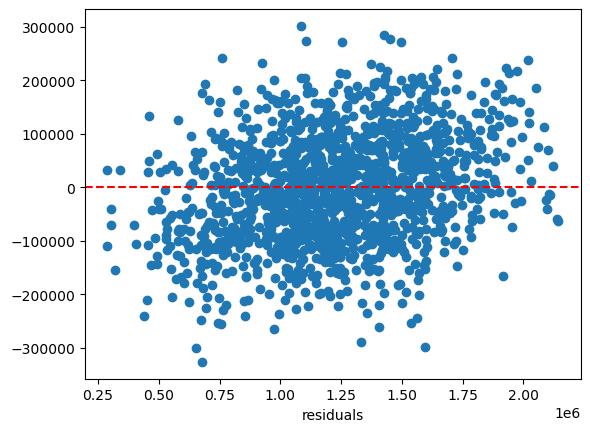

In [35]:
residuals=y_test-y_pred
plt.scatter(y_test,residuals)
plt.axhline(y=0,color='r',linestyle='--')
plt.xlabel('residuals')
plt.show()


In [114]:
from sklearn.linear_model import Ridge,Lasso,LassoCV

In [107]:
#lasso and ridge is used to reduce coefficient value in the model

ridge=Ridge(alpha=0.1)
ridge.fit(x_train,y_train)
y_pred_rid=ridge.predict(x_test)
r2_score(y_test,y_pred_rid)

0.9141004912486779

In [116]:
lassocv=LassoCV(alphas=[0.1,0.3,0.5,0.9,1,2,5,10],cv=5)
lassocv.fit(x_train,y_train)
print('best apha value',lassocv.alpha_)

best apha value 10.0


In [111]:
lasso=Lasso(alpha=0.1)
lasso.fit(x_train,y_train)
y_pred_lasso=lasso.predict(x_test)
r2_score(y_test,y_pred_lasso)

0.9141003657613189

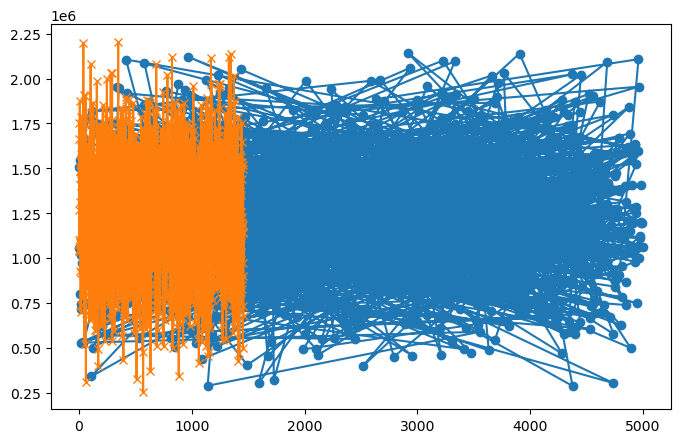

In [112]:
plt.figure(figsize=(8,5))
plt.plot(y_test,label='test',marker='o')
plt.plot(y_pred_lasso,label='pred_las',marker='x')
plt.show()

R²: 0.12
MAE: 33333.333333333336
MSE: 35010901.333333336
RMSE: 5917.0010421947145


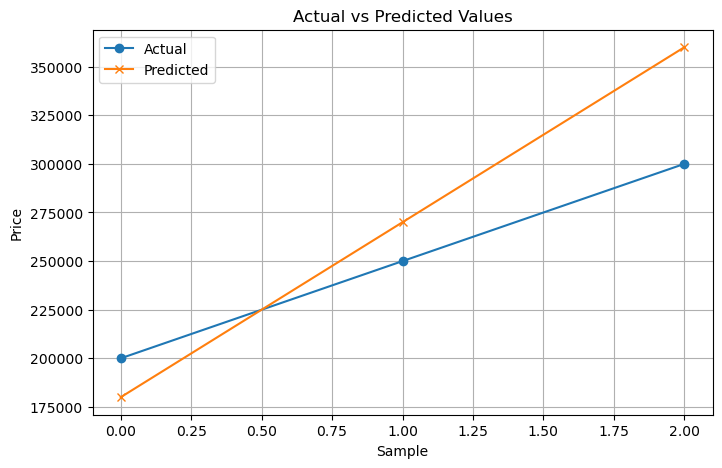

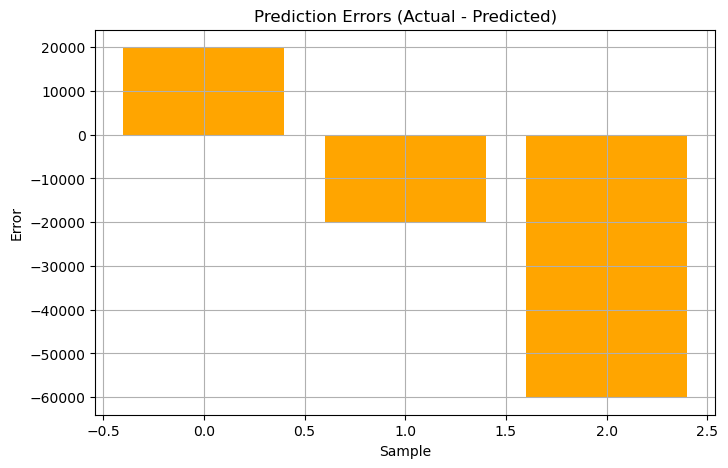

In [104]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Example data
y_true = np.array([200000, 250000, 300000])
y_pd = np.array([180000, 270000, 360000])

# Metrics
r2 = r2_score(y_true, y_pd)
mae = mean_absolute_error(y_true, y_pd)
mse = mean_squared_error(y_true, y_pd)
rmse = np.sqrt(mse)

print("R²:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

# Plot Actual vs Predicted
plt.figure(figsize=(8,5))
plt.plot(y_true, label='Actual', marker='o')
plt.plot(y_pd, label='Predicted', marker='x')
plt.title('Actual vs Predicted Values')
plt.xlabel('Sample')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Plot Errors
errors = y_true - y_pd
plt.figure(figsize=(8,5))
plt.bar(range(len(errors)), errors, color='orange')
plt.title('Prediction Errors (Actual - Predicted)')
plt.xlabel('Sample')
plt.ylabel('Error')
plt.grid(True)
plt.show()
